In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Prepare paths of input images and target segmentation masks

In [2]:
import os

input_dir = "/content/drive/MyDrive/Assignment 8/oxford_pet/images/"
target_dir = "/content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/"
img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7446
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_1.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_1.png
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_10.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_10.png
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_100.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_100.png
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_101.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_101.png
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_102.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_102.png
/content/drive/MyDrive/Assignment 8/oxford_pet/images/Abyssinian_103.jpg | /content/drive/MyDrive/Assignment 8/oxford_pet/annotations/trimaps/Abyssinian_103.png
/content/drive/M

### input image and corresponding segmentation mask

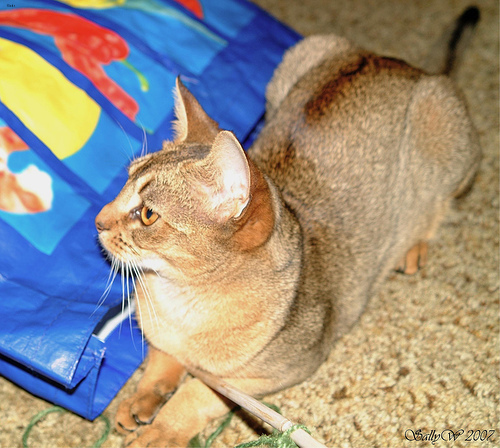

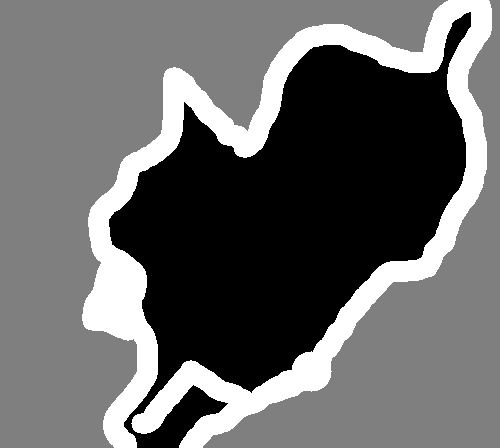

In [3]:
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps

# Display input image #7
display(Image(filename=input_img_paths[9]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = ImageOps.autocontrast(load_img(target_img_paths[9]))
display(img)

### Prepare dataset to load & vectorize batches of data

In [4]:
import keras
import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io


def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        input_img = tf_image.convert_image_dtype(input_img, "float32")

        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)


### Prepare U-Net Xception-style model

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))

    ### [First half of the network: downsampling inputs] ###

    # Entry block
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    # Downsampling blocks
    for filters in [64, 128, 256]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(filters, 1, strides=2, padding="same")(previous_block_activation)
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    ### [Second half of the network: upsampling inputs] ###

    for filters in [256, 128, 64, 32]:
        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.UpSampling2D(2)(x)

        # Project residual
        residual = layers.UpSampling2D(2)(previous_block_activation)
        residual = layers.Conv2D(filters, 1, padding="same")(residual)
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    # Final classification layer
    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    # Resize output to match input size
    outputs = layers.Resizing(img_size[0], img_size[1])(outputs)

    # Define the model
    model = keras.Model(inputs, outputs)
    return model

# Example usage
img_size = (128, 128)     # Change to your input size
num_classes = 3           # Change to number of segmentation classes

model = get_model(img_size, num_classes)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 64,    │          0 │ activation_15[0]… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 64, 64,    │      2,400 │ activation_16[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 64, 64,    │      4,736 │ activation_17[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      2,112 │ activation_15[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 64)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 32, 32,    │          0 │ add_7[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 32, 32,    │      8,896 │ activation_18[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 2,058,979 (7.85 MB)

 Trainable params: 2,055,203 (7.84 MB)

 Non-trainable params: 3,776 (14.75 KB)

### Set aside a validation split

In [13]:
import random

# Combine input and target paths into pairs and shuffle them together
img_mask_pairs = list(zip(input_img_paths, target_img_paths))
random.Random(1337).shuffle(img_mask_pairs)

# Split the shuffled pairs into training and validation sets
val_samples = 1000
train_img_mask_pairs = img_mask_pairs[:-val_samples]
val_img_mask_pairs = img_mask_pairs[-val_samples:]

# Separate the input and target paths for each set
train_input_img_paths, train_target_img_paths = zip(*train_img_mask_pairs)
val_input_img_paths, val_target_img_paths = zip(*val_img_mask_pairs)

# Instantiate dataset for each split
train_dataset = get_dataset(
    batch_size,
    img_size,
    list(train_input_img_paths), # Convert back to list for get_dataset
    list(train_target_img_paths), # Convert back to list for get_dataset
)
valid_dataset = get_dataset(
    batch_size, img_size, list(val_input_img_paths), list(val_target_img_paths)
)

### Train the model

In [14]:
# Configure the model for training.
# We use the "sparse" version of categorical_crossentropy
# because our target data is integers.
model.compile(
    optimizer=keras.optimizers.Adam(1e-4), loss="sparse_categorical_crossentropy"
)

# Train the model, doing validation at the end of each epoch.
epochs = 50

model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=valid_dataset,
    verbose=2,
)


Epoch 1/50
200/200 - 99s - 497ms/step - loss: 1.0036 - val_loss: 1.1256
Epoch 2/50
200/200 - 51s - 253ms/step - loss: 0.8073 - val_loss: 1.0529
Epoch 3/50
200/200 - 80s - 400ms/step - loss: 0.7826 - val_loss: 0.7942
Epoch 4/50
200/200 - 50s - 251ms/step - loss: 0.7703 - val_loss: 0.7643
Epoch 5/50
200/200 - 84s - 420ms/step - loss: 0.7620 - val_loss: 0.7643
Epoch 6/50
200/200 - 80s - 399ms/step - loss: 0.7550 - val_loss: 0.7646
Epoch 7/50
200/200 - 79s - 393ms/step - loss: 0.7479 - val_loss: 0.7678
Epoch 8/50
200/200 - 45s - 226ms/step - loss: 0.7388 - val_loss: 0.7767
Epoch 9/50
200/200 - 84s - 422ms/step - loss: 0.7247 - val_loss: 0.7997
Epoch 10/50
200/200 - 46s - 231ms/step - loss: 0.7017 - val_loss: 0.8484
Epoch 11/50
200/200 - 83s - 414ms/step - loss: 0.6679 - val_loss: 0.9208
Epoch 12/50
200/200 - 80s - 402ms/step - loss: 0.6281 - val_loss: 1.0060
Epoch 13/50
200/200 - 86s - 431ms/step - loss: 0.5890 - val_loss: 1.0494
Epoch 14/50
200/200 - 45s - 224ms/step - loss: 0.5782 - val_

### Visualize predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


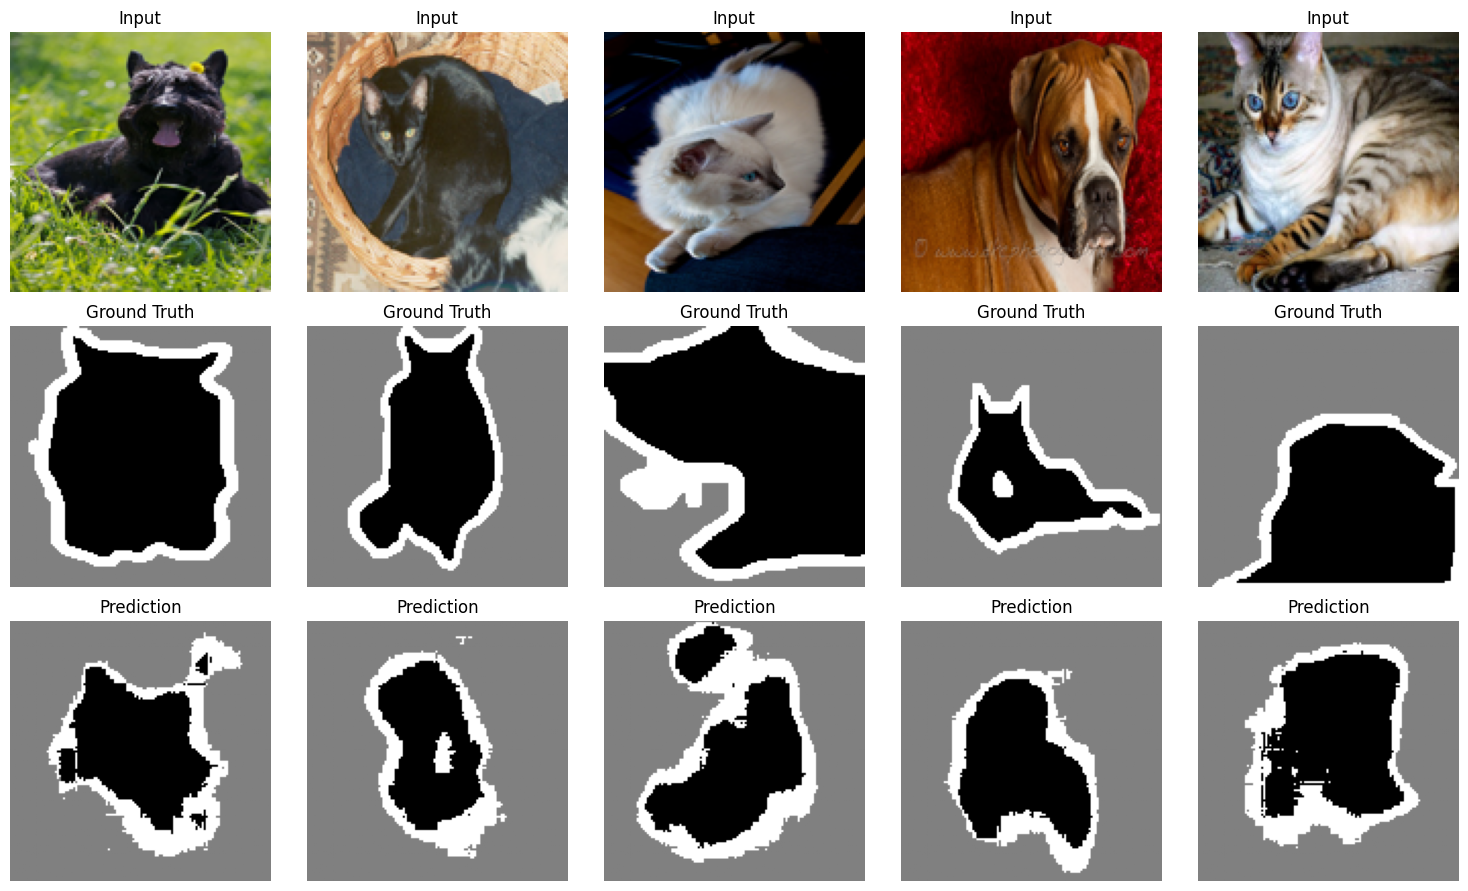

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf

# Load & preprocess single image for display
def load_display_image(path, size):
    img = Image.open(path).convert("RGB").resize(size)
    return np.array(img)

def load_display_mask(path, size):
    mask = Image.open(path).convert("L").resize(size, resample=Image.NEAREST)
    return np.array(mask)

# Ensure prediction is categorical class index
def decode_pred_mask(pred):
    pred_mask = np.argmax(pred, axis=-1)
    return pred_mask.astype(np.uint8)

# Run prediction on a small subset
num_samples = 5
val_img_paths = list(val_input_img_paths)[:num_samples]
val_mask_paths = list(val_target_img_paths)[:num_samples]

# Load images and masks manually (for alignment)
val_imgs = np.array([load_img_array(p, size=img_size) for p in val_img_paths])
val_preds = model.predict(val_imgs)

# Plot
plt.figure(figsize=(15, 9))

for i in range(num_samples):
    # Row 1: Original image
    img = load_display_image(val_img_paths[i], img_size)
    plt.subplot(3, num_samples, i + 1)
    plt.imshow(img)
    plt.title("Input")
    plt.axis("off")

    # Row 2: Ground-truth mask
    true_mask = load_display_mask(val_mask_paths[i], img_size)
    plt.subplot(3, num_samples, num_samples + i + 1)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Row 3: Predicted mask
    pred_mask = decode_pred_mask(val_preds[i])
    plt.subplot(3, num_samples, 2 * num_samples + i + 1)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()


Sample 1:
 - Ground truth classes: [1 2 3]
 - Predicted classes   : [0 1 2]
Sample 2:
 - Ground truth classes: [1 2 3]
 - Predicted classes   : [0 1 2]
Sample 3:
 - Ground truth classes: [1 2 3]
 - Predicted classes   : [0 1 2]
Sample 4:
 - Ground truth classes: [1 2 3]
 - Predicted classes   : [0 1 2]
Sample 5:
 - Ground truth classes: [1 2 3]
 - Predicted classes   : [0 1 2]


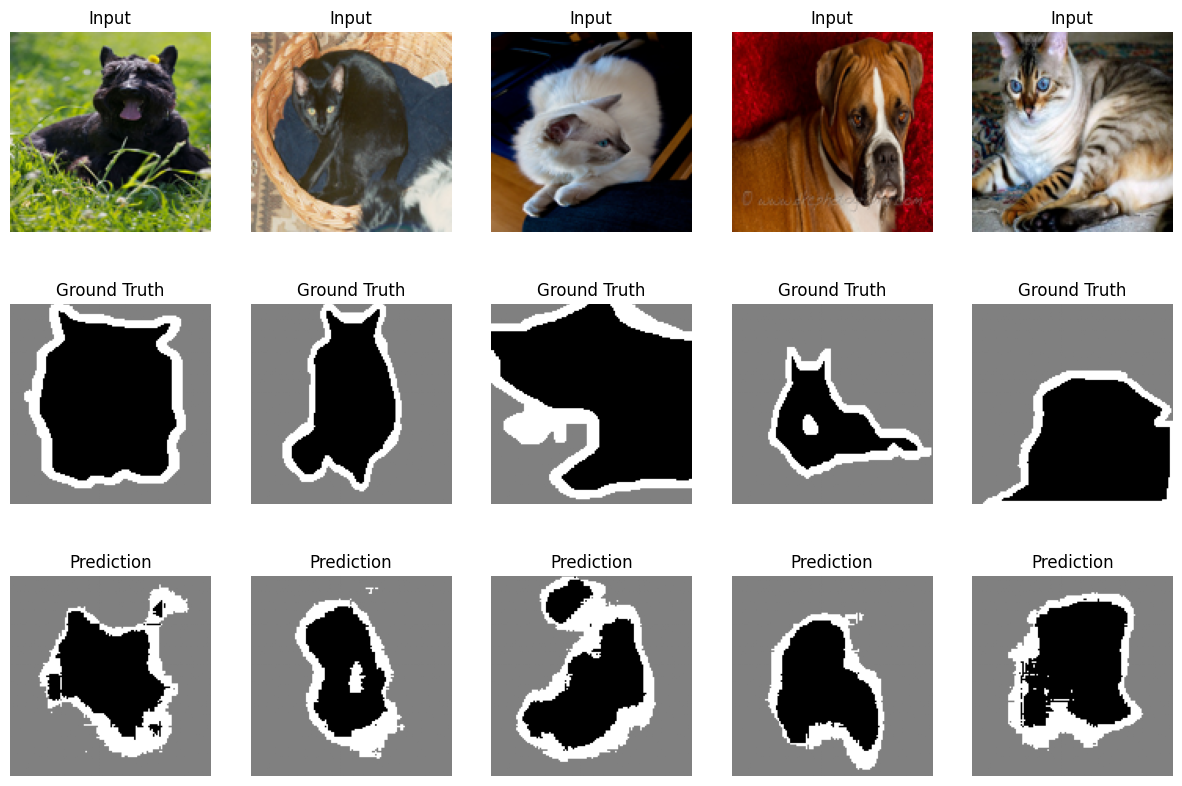

In [18]:
plt.figure(figsize=(15,10))
for i in range(num_samples):
    # Row 1: Original image
    img = load_display_image(val_img_paths[i], img_size)
    plt.subplot(3, num_samples, i + 1)
    plt.imshow(img)
    plt.title("Input")
    plt.axis("off")

    # Row 2: Ground-truth mask
    true_mask = load_display_mask(val_mask_paths[i], img_size)
    plt.subplot(3, num_samples, num_samples + i + 1)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Row 3: Predicted mask
    pred_mask = decode_pred_mask(val_preds[i])
    plt.subplot(3, num_samples, 2 * num_samples + i + 1)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    # 🔍 Debug: Print unique values in true and predicted mask
    print(f"Sample {i+1}:")
    print(" - Ground truth classes:", np.unique(true_mask))
    print(" - Predicted classes   :", np.unique(pred_mask))
